In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load the dataset
df = pd.read_csv('testing_data_final.csv')

In [10]:
# Define the features and target variable
features = [
    'sem_present_count', 'sem_absent_count', 'sem_eval_lec_test_1_mark',
    'sem_eval_lab_test_1_mark', 'semester_evaluation_mid_mark',
    'sem_eval_lec_test_2_mark', 'sem_eval_lab_test_2_mark',
    'semester_evaluation_pre_gtu_mark', 'semester_evaluation_internal_mark'
]
target = 'semester_evaluation_gtu_mark'

X = df[features]
y = df[target]

In [11]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Initialize a StandardScaler and fit it on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Initialize the RandomForestRegressor
rf_regressor = RandomForestRegressor(random_state=42)

In [14]:
# Define the grid of hyperparameters to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [15]:
# Setup GridSearchCV
grid_search = GridSearchCV(estimator=rf_regressor, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

In [16]:
# Perform the grid search and fit the model
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error', verbose=2)

In [17]:
# Extract the best estimator
best_rf = grid_search.best_estimator_

In [18]:
# Predict on the test set
y_pred = best_rf.predict(X_test_scaled)

In [19]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [20]:
# Display the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 1.58
Mean Squared Error (MSE): 4.09
Root Mean Squared Error (RMSE): 2.02


In [21]:
# Optionally, print the best hyperparameters
print("Best hyperparameters found:", grid_search.best_params_)

Best hyperparameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [22]:
# Extract feature importances
feature_importances = best_rf.feature_importances_
importances_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

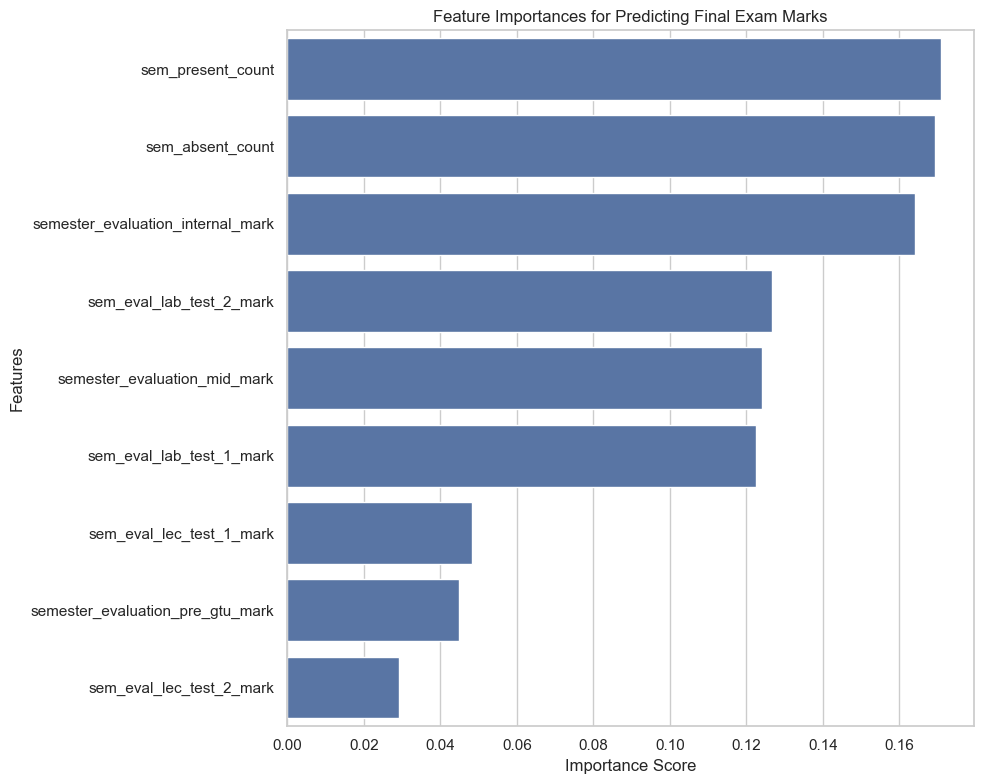

In [23]:
# Visualization of Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importances_df)
plt.title('Feature Importances for Predicting Final Exam Marks')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [26]:
# Save the best model and the scaler to files
with open('best_rf_model.pkl', 'wb') as model_file:
    pickle.dump(best_rf, model_file)
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
    # Save the feature importances for later use in the Flask app
with open('feature_importances.pkl', 'wb') as fi_file:
    # Convert the DataFrame to a dictionary for easier JSON serialization
    pickle.dump(importances_df.to_dict(orient='records'), fi_file)
